### Stochastic interpolant demo: unit Gaussian → Gaussian mixture 

A minimal, self-contained illustration of the `eesi` interpolant framework in 2D.

We learn a generative map from a simple **base** distribution to a more complex
**target**:

- **Base** `p_0`: a single 2D Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1`: a 2D Gaussian mixture model with randomized mean and covariances.

The `EESI` model trains a drift field `b(t, x)` and (optionally) score field `s(t, x)` along
the stochastic interpolant

$$x_t = \alpha(t)\,x_0 + \beta(t)\,x_1 + \gamma(t)\,z,\qquad z\sim N(0, I),$$

then estimates the entropy difference using a variety of strategies:
- integrate the learned probability-flow ODE (or reverse-time SDE) from
`t=0` (base) to `t=1` (target), acculumating entropy as `b * s` along the paths. 
- directly sample the interpolant, taking the average of `b * s`
- directly sample the interpolant, taking the average of `div(b)` independent of the score

This notebook covers **setup & instantiation**,
the **training loop**, **sampling**, and **contour plotting**.

In [2]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
from torch.distributions import MultivariateNormal

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
from eesi import EESI, TimeMLP, GaussianMixture

%matplotlib inline
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a two-component Gaussian
mixture built from `eesi.datasets.GaussianMixture`, whose weights, means and
full (correlated) covariances are drawn once from a fixed `seed` and then held
constant.

In [3]:
d = 32
# --- base: single 2D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(d, device=device), torch.eye(d, device=device))

# --- target: 3-component Gaussian mixture from eesi.datasets.GaussianMixture ---
# The mixture draws its weights, means and full covariances once (fixed `seed`)
# and holds them constant; `sigma` sets how far apart the component means are.
target = GaussianMixture(d=d, n=5, sigma=4.0, seed=5, device=device)

# Sanity check: draw and scatter samples from each distribution.
x0_vis = base.sample((2000,)).cpu()
x1_vis = target.sample((2000,)).cpu()

'''
# Symmetric plot limits that comfortably contain both distributions.
LIM = float(torch.cat([x0_vis, x1_vis]).abs().max().ceil()) + 1.0

fig, ax = plt.subplots(1, 2, figsize=(5, 3), sharex=True, sharey=True)
ax[0].scatter(x0_vis[:, 0], x0_vis[:, 1], s=4, alpha=0.3, c="steelblue")
ax[0].set_title("base  $p_0 = N(0, I)$")
ax[1].scatter(x1_vis[:, 0], x1_vis[:, 1], s=4, alpha=0.3, c="crimson")
ax[1].set_title("target  $p_1$ (Gaussian mixture)")
for a in ax:
    a.set_aspect("equal"); a.set_xlim(-LIM, LIM); a.set_ylim(-LIM, LIM)
plt.show()
'''

'\n# Symmetric plot limits that comfortably contain both distributions.\nLIM = float(torch.cat([x0_vis, x1_vis]).abs().max().ceil()) + 1.0\n\nfig, ax = plt.subplots(1, 2, figsize=(5, 3), sharex=True, sharey=True)\nax[0].scatter(x0_vis[:, 0], x0_vis[:, 1], s=4, alpha=0.3, c="steelblue")\nax[0].set_title("base  $p_0 = N(0, I)$")\nax[1].scatter(x1_vis[:, 0], x1_vis[:, 1], s=4, alpha=0.3, c="crimson")\nax[1].set_title("target  $p_1$ (Gaussian mixture)")\nfor a in ax:\n    a.set_aspect("equal"); a.set_xlim(-LIM, LIM); a.set_ylim(-LIM, LIM)\nplt.show()\n'

### 2. Model & sampler setup

`EESI` wraps two `TimeMLP` fields — the drift `net_b` and the score `net_s`.

- `path="trig2"` uses the ramped interpolant `x_t = cos^2(\u03c0t/2) x_0 + sin^2(\u03c0t/2) x_1`,
  whose velocity vanishes at both endpoints.
- `gamma="sqrt"` adds the latent-noise schedule `\u03b3(t) = sqrt(t(1-t))`, so the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate). Try `gamma="sin2"` / `gamma="none"`, or `path="linear"`/`"trig"`.


In [4]:
net_b = TimeMLP(d=d, hidden=512, n_layers=4, activation="silu")
net_s = TimeMLP(d=d, hidden=512, n_layers=6, activation="silu")

model = EESI(
    net_b, net_s,
    d=d,
    path="trig2",
    gamma="sin2",
    gamma_scale=1.0,
    learn_score=True
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
#print(model)
print(sum(p.numel() for p in model.net_b.parameters()))
print(sum(p.numel() for p in model.net_s.parameters()))


821792
1347104


### 3. Training loop
For demonstrating the effect of limited data, we sample `x1` just once
as we assume this is difficult to sample.
Each iteration then draws a fresh batch from the base `x_0`, forms the interpolant
internally, and returns the drift/score losses. We minimise their sum.

In [11]:


n_iters = 1000
n_samples = 200000
bsize = 10000
nbatches = n_samples//bsize
hist_b, hist_s = [], []
for it in range(n_iters):

    #print(nbatches)
    for b in range(nbatches):
        #print(b)
        # so we always grab the same data when needed
        # in real situations, sampling p1 is probably difficult
        torch.manual_seed(b)
        x1 = target.sample((bsize,))

        # reset seed to sample base randomly (always easy in practice)
        torch.seed()
        x0 = base.sample((bsize,))
        losses = model.loss(x1, x0)          # {"b": drift loss, "s": score loss}
        loss = losses["b"] + losses["s"]

        opt.zero_grad()
        loss.backward()
        opt.step()

    hist_b.append(losses["b"].item())
    hist_s.append(losses["s"].item())
    if it % 100 == 0:
        print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")
print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")


iter    0  loss_b=-238.160  loss_s=-12.958
iter  100  loss_b=-235.232  loss_s=-13.136
iter  200  loss_b=-235.493  loss_s=-12.959
iter  300  loss_b=-237.956  loss_s=-13.194
iter  400  loss_b=-236.484  loss_s=-13.193
iter  500  loss_b=-241.317  loss_s=-13.257
iter  600  loss_b=-242.138  loss_s=-13.351
iter  700  loss_b=-238.523  loss_s=-13.403
iter  800  loss_b=-236.368  loss_s=-13.566
iter  900  loss_b=-235.298  loss_s=-13.655
iter  999  loss_b=-237.987  loss_s=-13.018


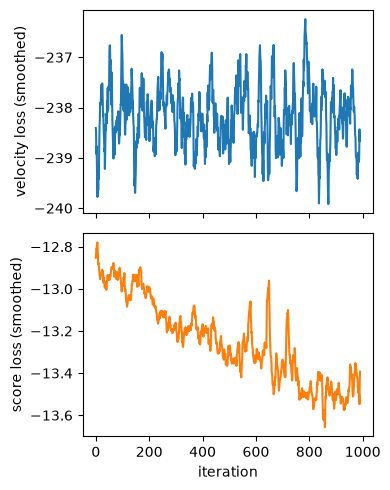

In [12]:
# Training curves (smoothed).
def smooth(v, k=10):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(2,1,sharex=True,figsize=(4,5))
ax[0].plot(smooth(hist_b),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Map base samples to the target with the model's built-in samplers:

- `model.sample_ode` integrates the probability-flow **ODE** `dx/dt = b(t, x)`
  with Heun's method (drift only).
- `model.sample_sde` integrates the reverse-time **SDE** with Euler–Maruyama,
  using both the drift `b` and the learned score `s` (diffusion `eps`).

In [13]:
# Draw base samples and push them through the model's built-in samplers.
torch.manual_seed(5)
torch.seed()
x0 = base.sample((100000,))
x1 = target.sample((100000,))
gen_ode = model.sample_ode(x0, n_steps=100)            # probability-flow ODE (drift only)
gen_sde = model.sample_sde(x0, n_steps=100, eps=0.4)     # reverse-time SDE (drift + score)

# How well do generated samples match the target? (mean log-density)
ref = target.log_prob(x1).mean()
base_ref = base.log_prob(x0).mean()
base_target = target.log_prob(x0).mean()
print(f"mean target log-prob \u2014 true target : {ref:+.3f}")
print(f"mean target log-prob \u2014 ODE sampler : {target.log_prob(gen_ode).mean():+.3f}")
print(f"percent error in log-prod, ODE sampler : {100*(target.log_prob(gen_ode).mean()-ref)/ref:+.3f}%")
print(f"mean target log-prob \u2014 SDE sampler : {target.log_prob(gen_sde).mean():+.3f}")
print(f"percent error in log-prod, SDE sampler : {100*(target.log_prob(gen_sde).mean()-ref)/ref:+.3f}%")
print(f"mean base   log-prob \u2014 true base   : {base_ref:+.3f}")
print(f"mean target log-prob \u2014 true base   : {base_target:+.3f}")
print(f"estimated entropy change : {-ref + base_ref:+.3f}")
delta_pred = -ref + base_ref
delta_pred = delta_pred.cpu().numpy()


mean target log-prob — true target : -55.761
mean target log-prob — ODE sampler : -55.668
percent error in log-prod, ODE sampler : -0.167%
mean target log-prob — SDE sampler : -55.532
percent error in log-prod, SDE sampler : -0.410%
mean base   log-prob — true base   : -45.393
mean target log-prob — true base   : -154.710
estimated entropy change : +10.368


### 4b. Contour plotting

The analytic target density with generated samples overlaid — the **ODE**
sampler on the left, the **SDE** sampler on the right. Both should populate the
same modes as the target.


In [22]:
# Evaluate the target density on a grid (on-device), then move to CPU for plotting.
lo, hi, n = -LIM, LIM, 200
xs = torch.linspace(lo, hi, n, device=device)
gx, gy = torch.meshgrid(xs, xs, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=-1)
dens = target.log_prob(grid).exp().reshape(n, n)
dens = target.log_prob(grid).reshape(n, n)
gx, gy, dens = gx.cpu(), gy.cpu(), dens.cpu()

fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)
for a, samples, title in [(ax[0], gen_ode, "ODE sampler"), (ax[1], gen_sde, "SDE sampler")]:
    s = samples.cpu()
    a.contourf(gx, gy, dens, levels=25, cmap="Blues")
    a.scatter(s[:, 0], s[:, 1], s=3, c="crimson", alpha=0.25)
    a.set_title(f"target density + {title}")
    a.set_aspect("equal"); a.set_xlim(lo, hi); a.set_ylim(lo, hi)
plt.show()


NameError: name 'LIM' is not defined

### 5. Entropy along the paths

The trajectory-returning `*_entropy_traj` samplers augment every path with the
running integral

$$\Delta\text{S}(t) = -\int_0^t b(x_{t'}, t')\cdot s(x_{t'}, t')\,dt',$$

an estimate of how the (differential) entropy of the flowing density changes as
samples move from base to target. With `sample_ode_entropy_traj` we get the full
`ΔS(t)` curve for every sample at once, so we can plot many paths together
and read off the ensemble-mean entropy change.

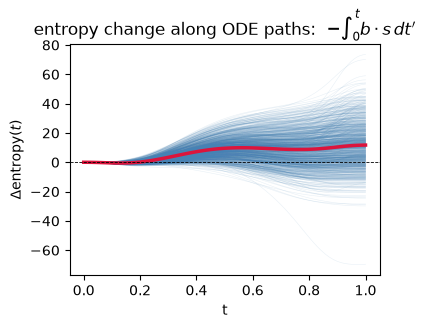

10.367645
11.319509
0.09116533
0.09181094


In [14]:
# Trace the running entropy change along many SDE paths.
torch.seed()
batch = 20000

means = []
for k in range(20):
    x0 = base.sample((batch,))
    traj, ent_traj, ts = model.sample_ode_entropy_traj(x0, n_steps=100)
    means.append(ent_traj[-1, :].mean().cpu().numpy())

ts_c = ts.cpu().numpy()
ent_c = ent_traj.cpu().numpy()[:, :1000]         # first 1000 paths [n_steps+1, B]

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c, c="steelblue", lw=0.4, alpha=0.12)                  # individual paths
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta$entropy$(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
plt.show()

print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


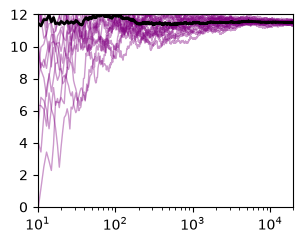

11.489246
0.10253772
0.11050408


In [37]:
# Examine convergence based on number of trajectories simulated
vals = []
torch.seed()
batch = 20000

plt.figure(figsize=(3.3,2.5))

mom = []
for k in range(20):
    x0 = base.sample((batch,))
    x,ent = model.sample_ode_entropy(x0, n_steps=100)
    ent_cpu = ent.cpu().numpy()
    vals.append(np.mean(ent_cpu))
    #print(np.mean(ent_cpu))
    mean = np.cumsum(ent_cpu)/np.arange(1,batch+1)
    mom.append(mean)
    plt.plot(np.arange(1,batch+1),mean,'-',color='purple',alpha=0.4,lw=1)
mom = np.mean(mom,axis=0)
plt.plot(np.arange(1,batch+1),mom,'-',color='k',lw=2)
#plt.yscale('log')
plt.xscale('log')
plt.xlim(10,20000)
plt.ylim(0,12)
plt.show()
print(np.mean(vals))
print(np.std(vals))
print((np.mean(vals)-delta_pred)/delta_pred)


### 6. Generation-Free Entropy Estimate

In [18]:
torch.manual_seed(1)
batch = 1000
x1 = target.sample((batch,))

means = []
for n in range(1000):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate_dot(x1, x0)   # b*s formulation
    means.append(ent.mean().cpu().numpy())
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


10.237774
0.713218
-0.0125266025


Somewhat less accurate than I'd like. Not sure why exactly. Perhaps there is some reparameterization or conditioning that can be done to improve this.

In [17]:
torch.manual_seed(1)
batch = 1000
x1 = target.sample((batch,))

means = []
for n in range(1000):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate_div(x1, x0)   # div(b) formulation
    means.append(ent.mean().detach().cpu().numpy())
print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


10.367645
10.014814
0.5419193
-0.03403192
